# 05 -- Calculus review: derivative, integral, Taylor, gradient

| question | answer |
|---|---|
| What physics problem? | Velocity is the rate of change of position; work is the integral of force. |
| What mathematics? | Limits, the derivative, the definite integral, the fundamental theorem, Taylor series, the gradient. |
| What algorithm? | Finite-difference differentiation and trapezoid/Simpson integration; automatic differentiation. |
| What software? | SymPy for exact calculus; NumPy/SciPy for numerics; optional PyTorch autograd. |
| What experiment? | A position sensor is differentiated to velocity; a power meter is integrated to energy. |
| What engineering application? | Firmware differences an ADC stream; a running sum integrates it; autograd is backpropagation. |

This notebook follows the repository template: English explanation, mathematical derivation,
dimensions and SI units, SymPy derivation, NumPy implementation, Pandas tables, Matplotlib plots,
optional PyTorch, exercises, and engineering applications. It reuses the `physkit` package and the
results of earlier chapters.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
import physkit
from physkit import constants as C, units as U, linalg as la
from physkit.plotting import use_style
use_style()
torch = physkit.optional_torch()            # None if PyTorch is unavailable; NumPy stays authoritative
sp.init_printing()
print("physkit", physkit.__version__, "| numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

physkit 0.1.0 | numpy 2.4.6 | torch: absent (optional)


## English explanation

Calculus turns a signal into its rate of change (the **derivative**) and accumulates a rate into
a total (the **integral**); the **fundamental theorem** says these undo each other. The **Taylor
series** approximates a smooth function by a polynomial near a point -- the basis of every numerical
method that follows. In three dimensions the **gradient** points uphill on a scalar field. This
chapter fixes the exact results (SymPy) and their numerical counterparts (NumPy), building on the
floating-point care of chapter 00.

Subject-verb-object: the derivative measures the rate; the integral accumulates the total; the
gradient points uphill.

## Mathematical derivation

The derivative is the limit $f'(x)=\lim_{h\to0}\frac{f(x+h)-f(x)}{h}$; the central difference
$\frac{f(x+h)-f(x-h)}{2h}$ approximates it with error $O(h^2)$. The definite integral is the limit of
Riemann sums, and the **fundamental theorem** gives $\int_a^b f'(x)\,dx=f(b)-f(a)$. Taylor's theorem
writes $f(x)=\sum_{n\ge0}\frac{f^{(n)}(a)}{n!}(x-a)^n$; truncating gives a polynomial approximant. The
gradient of $f(x,y)$ is $\nabla f=(\partial_x f,\partial_y f)$.

## Dimensions and SI units

Differentiating with respect to time divides the dimension by time, integrating over time
multiplies by it. So $\frac{d}{dt}[\text{position}]$ is a velocity and $\frac{d}{dt}[\text{velocity}]$
an acceleration, while $\int[\text{power}]\,dt$ is an energy. `physkit.units` confirms the bookkeeping.

In [2]:
x = U.LENGTH; t = U.TIME
velocity = x / t; acceleration = velocity / t
print("d(position)/dt ->", velocity, "(VELOCITY:", velocity == U.VELOCITY, ")")
print("d(velocity)/dt ->", acceleration, "(ACCELERATION:", acceleration == U.ACCELERATION, ")")
energy = U.POWER * U.TIME                         # integral of power over time
print("int(power) dt ->", energy, "(ENERGY:", energy == U.ENERGY, ")")
assert velocity == U.VELOCITY and energy == U.ENERGY

d(position)/dt -> L^1 T^-1 (VELOCITY: True )
d(velocity)/dt -> L^1 T^-2 (ACCELERATION: True )
int(power) dt -> L^2 M^1 T^-2 (ENERGY: True )


## SymPy derivation

SymPy differentiates and integrates exactly, and verifies the fundamental theorem and a Taylor
expansion.

In [3]:
xs = sp.symbols('x', real=True)
f = sp.sin(xs) * sp.exp(xs)
fp = sp.diff(f, xs)
print("d/dx [sin(x) e^x] =", sp.simplify(fp))
# fundamental theorem: integral of f' from 0 to 1 equals f(1) - f(0)
ftc = sp.integrate(fp, (xs, 0, 1)) - (f.subs(xs, 1) - f.subs(xs, 0))
assert sp.simplify(ftc) == 0
print("fundamental theorem verified: int_0^1 f' dx = f(1) - f(0)")
# Taylor series of sin about 0
print("sin(x) =", sp.series(sp.sin(xs), xs, 0, 8))

d/dx [sin(x) e^x] = sqrt(2)*exp(x)*sin(x + pi/4)
fundamental theorem verified: int_0^1 f' dx = f(1) - f(0)
sin(x) = x - x**3/6 + x**5/120 - x**7/5040 + O(x**8)


## NumPy implementation

The central-difference derivative and the trapezoid integral, checked against the exact SymPy
results. As in chapter 00, too small an $h$ reintroduces rounding error.

In [4]:
fnum = lambda x: np.sin(x)*np.exp(x)
fp_exact = lambda x: np.exp(x)*(np.sin(x)+np.cos(x))
x0, h = 1.3, 1e-5
central = (fnum(x0+h) - fnum(x0-h)) / (2*h)
print(f"central diff f'(1.3) = {central:.8f} | exact = {fp_exact(x0):.8f}")

# trapezoid integral of f' from 0 to 1 should recover f(1)-f(0)
xg = np.linspace(0, 1, 2001)
I = np.trapezoid(fp_exact(xg), xg)
print(f"trapezoid int f' [0,1] = {I:.6f} | f(1)-f(0) = {fnum(1)-fnum(0):.6f}")

central diff f'(1.3) = 4.51711340 | exact = 4.51711340
trapezoid int f' [0,1] = 2.287355 | f(1)-f(0) = 2.287355


## Pandas tables

Integration error falls with the number of panels: trapezoid as $O(N^{-2})$, Simpson as
$O(N^{-4})$.

In [5]:
from scipy.integrate import simpson
exact = fnum(1) - fnum(0)
rows = []
for N in (10, 20, 40, 80, 160):
    xg = np.linspace(0, 1, N+1)
    y = fp_exact(xg)
    rows.append({"N": N, "trapezoid_err": abs(np.trapezoid(y, xg) - exact),
                 "simpson_err": abs(simpson(y, x=xg) - exact)})
df = pd.DataFrame(rows)
print(df.to_string(index=False))

  N  trapezoid_err  simpson_err
 10       0.000782 5.080506e-06
 20       0.000195 3.176494e-07
 40       0.000049 1.985491e-08
 80       0.000012 1.240960e-09
160       0.000003 7.756018e-11


## Matplotlib plots

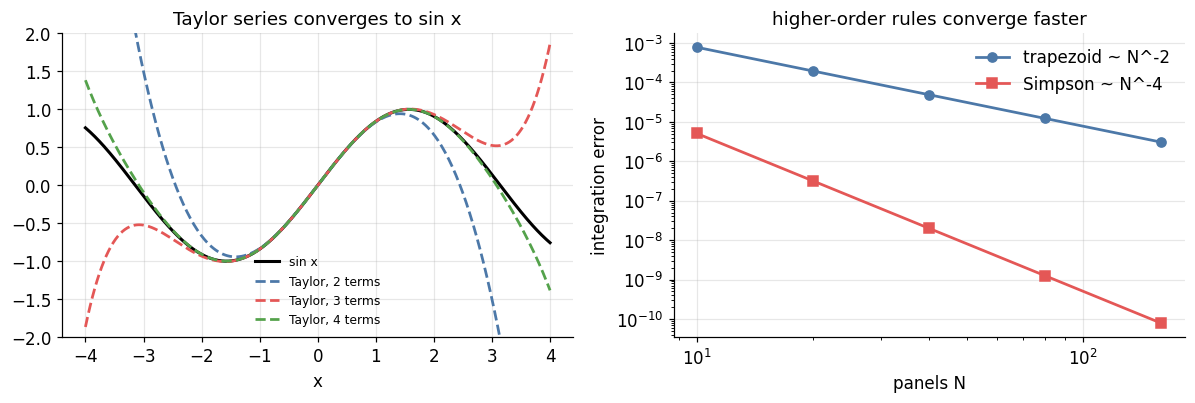

In [6]:
import math
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
xg = np.linspace(-4, 4, 400)
ax[0].plot(xg, np.sin(xg), "k", lw=2, label="sin x")
for terms in (2, 3, 4):                          # partial sums of the sine Taylor series
    approx = sum(((-1)**k)/math.factorial(2*k+1) * xg**(2*k+1) for k in range(terms))
    ax[0].plot(xg, approx, "--", label=f"Taylor, {terms} terms")
ax[0].set_ylim(-2, 2); ax[0].set_title("Taylor series converges to sin x"); ax[0].legend(fontsize=8)
ax[0].set_xlabel("x")
ax[1].loglog(df["N"], df["trapezoid_err"], "o-", label="trapezoid ~ N^-2")
ax[1].loglog(df["N"], df["simpson_err"], "s-", label="Simpson ~ N^-4")
ax[1].set_xlabel("panels N"); ax[1].set_ylabel("integration error"); ax[1].legend()
ax[1].set_title("higher-order rules converge faster")
plt.tight_layout(); plt.show()

## PyTorch (optional)

Automatic differentiation computes exact derivatives by the chain rule -- the same mechanism as
backpropagation. When present, PyTorch autograd reproduces the SymPy derivative.

In [7]:
if torch is not None:
    xv = torch.tensor(1.3, dtype=torch.float64, requires_grad=True)
    y = torch.sin(xv) * torch.exp(xv)
    y.backward()
    print(f"autograd f'(1.3) = {float(xv.grad):.8f} | exact = {fp_exact(1.3):.8f}")
else:
    print("PyTorch absent -- the central-difference and SymPy derivatives above are authoritative.")

PyTorch absent -- the central-difference and SymPy derivatives above are authoritative.


## Exercises

1. Plot the central-difference error of $f'(1.3)$ versus $h$ from $10^{-1}$ to $10^{-12}$ and
   find the optimal $h$ where truncation error meets rounding error (chapter 00).
2. Use SymPy to obtain the Taylor series of $e^x$, $\cos x$, and $\ln(1+x)$; identify the radius of
   convergence of the last.
3. Compute the gradient of $f(x,y)=x^2+y^2$ symbolically and numerically, and confirm it points
   radially outward.

## Engineering applications

A motion controller **differences** successive **ADC** position samples to estimate velocity --
the discrete central difference -- and low-pass filters the result because differentiation amplifies
high-frequency noise. A power meter **accumulates** samples with a running sum, the discrete integral,
to report energy. In machine learning and adaptive **DSP**, **autograd** propagates derivatives
through a computation graph; it is the calculus of this chapter applied at scale on a **GPU**.

Summary (subject-verb-object): the sensor supplies samples; the difference estimates the rate; the
running sum accumulates the total; autograd differentiates the graph.